In [97]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..','src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from DiagnosisTool.features import clean_diabetes_data
from DiagnosisTool.pipelines import build_diabetes_pipeline

module_path = os.path.abspath(os.path.join(module_path,'DiagnosisTool'))

if module_path not in sys.path:
    sys.path.append(module_path)

from data import download_diabetes_file
from data import load_diabetes_data

download_diabetes_file()

diabetes_data = load_diabetes_data()

diabetes_data = clean_diabetes_data(diabetes_data)

diabetes_data.describe()




Dataset URL: https://www.kaggle.com/datasets/mathchi/diabetes-data-set
Dataset URL: https://www.kaggle.com/datasets/mathchi/diabetes-data-set


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Figura 1 - Distribuição de variáveis

A figura 1 apresenta as distribuições das principais variáveis utilizadas
na modelagem, permitindo avaliar assimetria, presença de outliers e justificar
as decisóes de pré-processamento aplicadas

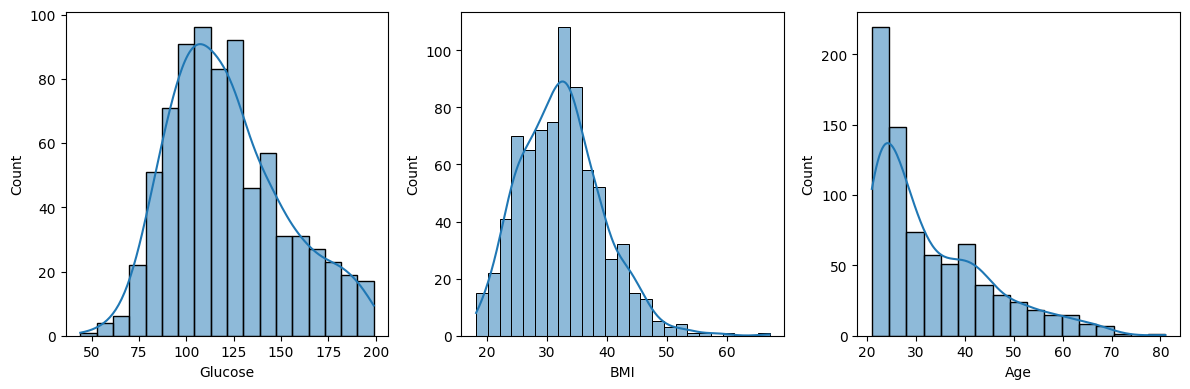

In [98]:
cols = ["Glucose", "BMI", "Age"]
plt.figure(figsize=(12, 4))
for i, col in enumerate(cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(diabetes_data[col], kde=True)
    plt.title = f"Distribution of {col}"

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/diabetes_data_distributions.png")

plt.show()  

### Figura 2 - Pipeline de Machine Learning

O diagrama do Pipeline de Machine Learning foi elaborado manualmente para representar
as etapas do processo de Machine Learning, desde a entrada dos dados
até a avaliação dos modelos 

### Figura 3 - Matriz de Confusão 

A matriz de confusão permite avaliar a distribuição de acertos e erros
do modelo de classificação aplicado ao dataset de Diabetes

Dataset URL: https://www.kaggle.com/datasets/mathchi/diabetes-data-set


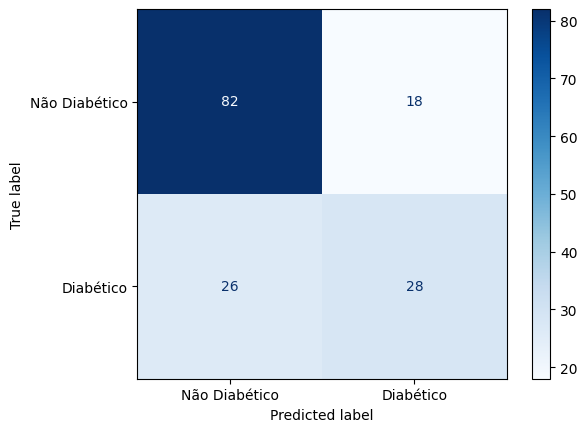

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from DiagnosisTool.data import load_diabetes_data
from DiagnosisTool.features import clean_diabetes_data, split_diabetes_data
from sklearn.model_selection import train_test_split

df = load_diabetes_data()
df = clean_diabetes_data(df)    
df.head()

X, y = split_diabetes_data(df, "Outcome")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = build_diabetes_pipeline()
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Diabético', 'Diabético'])

disp.plot(cmap=plt.cm.Blues)
plt.title = "Confusion Matrix - Diabetes"
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/diabetes_confusion_matrix.png")
plt.show()

### Figura 4 - Curvas ROC

A figura 4 apresenta as curvas ROC (Receiver Operating Characteristics) obtidas
para os modelos de classificação aplicados aos datasets analisados. Essa métrica
avalia a capacidade discriminativa dos modelos independentemente do limiar de
decisão, sendo especialmente relevante em problemas de classificação binária.
A área sob a curva ROC (AUC) indica o desempenho global do modelo, onde valores mais
próximos de 1 representam maior capacidade dde separação entre as classes.

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title ='ROC Curve - Diabetes Data'
plt.legend(loc="lower right")
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/diabetes_roc_curve.png")
plt.show()

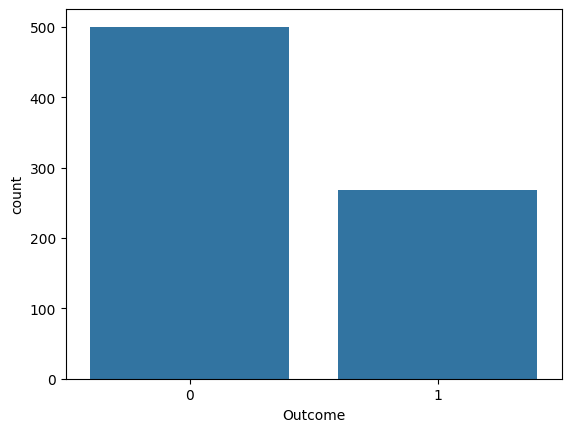

In [100]:
sns.countplot(x="Outcome", data=diabetes_data)
plt.title="Distribuição da variável Outcome"
plt.show()


### Discussão sobre Métricas de Outcome
- Normalmente observa-se <b>desbalanceamento moderado</b>
- Classe 0 (não diabético) costuma ser maior que Classe 1
- Isso impacta
    - Métricas de avaliação
    - Escolha de modelos
    - Possivelmente técnicas de balanceamento

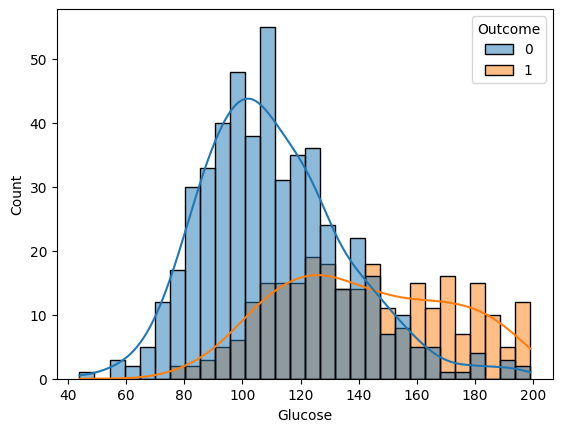

In [101]:
sns.histplot(data=diabetes_data, x="Glucose", hue="Outcome", kde=True, bins=30)
plt.title="Distribuição de Glucose por Classe"
plt.show()



### Discussão sobre Glucose por Classe
- Indivíduos com <b>Diabetes (Outcome = 1)</b> tendem a ter:
    - Médias mais altas de Glucose
    - Distribuição deslocada à direita
- Forte indicador preditivo

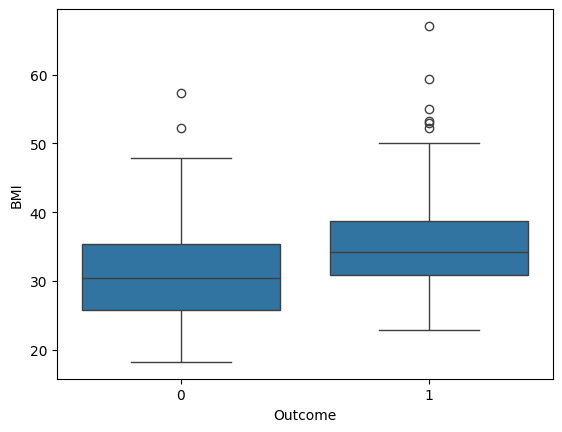

In [102]:
sns.boxplot(x="Outcome",y="BMI",data=diabetes_data)
plt.title="BMI por Classe"
plt.show()



### Discussão sobre BMI vs. Outcome
- Classe <b>diabética</b> costuma apresentar:
    - BMI médio mais alto
    - Maior variabilidade
- Relação positiva entre diabetes e obesidade é consistente com literatura médica
    

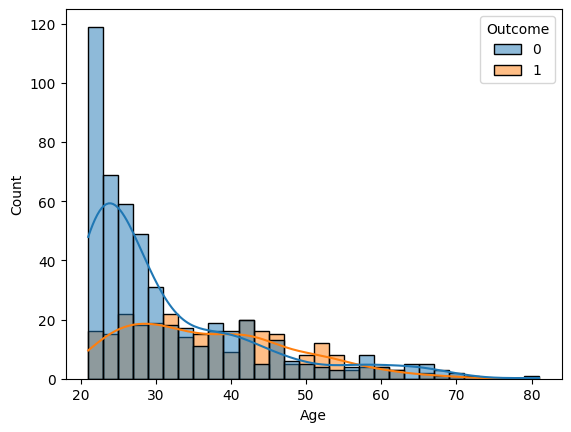

In [103]:
sns.histplot(data=diabetes_data, x="Age", hue="Outcome", kde=True, bins=30)
plt.title="Distribuição de Age por Classe"
plt.show()




### Discussão sobre Idade vs. Outcome
- Maior incidência de diabetes sobre idades mais altas
- Distribuição mais concentrada em faixas etárias superiores para Outcome = 1
- Idade deve ser considerada uma feature importante

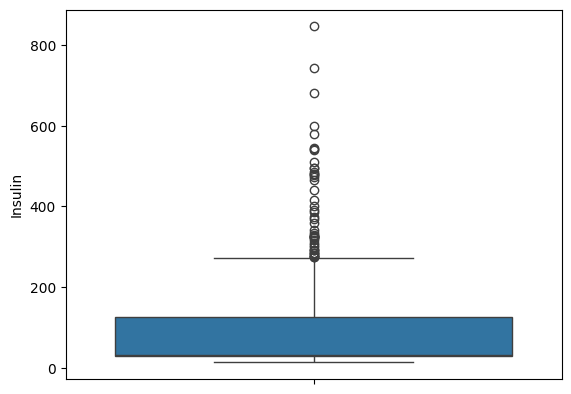

In [104]:
sns.boxplot(y="Insulin",data=diabetes_data)
plt.title="Distribuição de Insulin"
plt.show()



### Discussão sobre Insulina e Skin Thickness (atenção especial)
- Distribuição altamente assimétrica
- Presença de:
    - Muitos zeros
    - Outliers extremos
- Antes de usar no modelo:
    - Substituir zeros por NaN
    - Aplicar imputação
    - Possivelmente usar transformação logarítmica


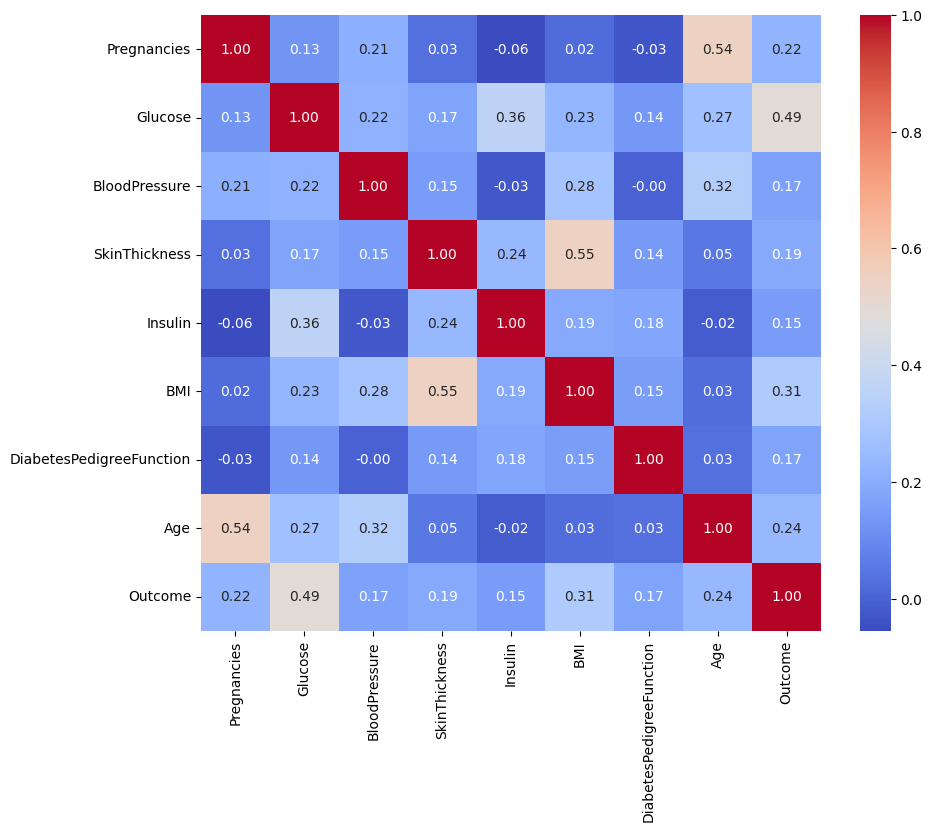

In [105]:
plt.figure(figsize=(10,8))
sns.heatmap(diabetes_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title="Matriz de Correlação"
plt.show()

### Pontos relevantes
- Glucose costuma ter a maior correlação com Outcome
- BMI e Idade também mostram correlação positiva
- Pouca multicolinearidade severa

### Discussão Geral dos resultados
#### Principais insights
- Glucose é a feature mais informativa
    - Clara separação entre as classes
- BMI e Idade são fateores de risco importantes
    - Coerente com evidências clínicas
- Zeros representam dados ausentes
    - Devem ser tratados antes do treinamento
- Dataset é relativamente pequeno
    - Modelos simples podem funcionar bem
    - Validação cruzada é recomendada